In [1]:
###### START ######

import pandas as pd
import statsmodels.api as sm

# Load the dataset
file_path = 'FinalProjectDataset.csv'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset for review
data.head()

,disc_hire,gender,age,edu_cat,mariage,emp_fin,income_quartile,birth_region,health,disability,residence,disc_wage,disc_jobedu,disc_promotion,disc_resign,disc_edu,disc_home,disc_social
0,1.0,0,3,1,2,0,0,0,1,0,1,1,0,0,0,0,0,0
1,0.0,1,3,1,2,1,1,0,2,0,1,0,0,0,0,0,0,0
2,0.0,1,1,2,0,1,1,0,2,0,1,0,0,0,0,0,0,0
3,0.0,1,1,2,1,0,3,0,1,0,1,0,0,0,0,0,0,0
4,1.0,0,3,0,1,0,1,0,2,0,1,0,0,0,0,0,0,1


In [2]:
####### QUESTION 1 #######



# Filtering the dataset to include only participants with 'disc_hire' as 0 or 1
filtered_data = data[data['disc_hire'].notna()]

# Preparing the data for logistic regression
X = filtered_data.drop('disc_hire', axis=1)  # Explanatory variables
y = filtered_data['disc_hire']               # Response variable

# Adding a constant to the model (intercept)
X = sm.add_constant(X)

# Fitting the logistic regression model
logistic_model = sm.Logit(y, X).fit()

# Displaying the summary of the logistic regression model
logistic_model.summary()


Optimization terminated successfully.
         Current function value: 0.310260
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              disc_hire   No. Observations:                 3479
Model:                          Logit   Df Residuals:                     3461
Method:                           MLE   Df Model:                           17
Date:                Fri, 15 Dec 2023   Pseudo R-squ.:                  0.3751
Time:                        02:59:41   Log-Likelihood:                -1079.4
converged:                       True   LL-Null:                       -1727.2
Covariance Type:            nonrobust   LLR p-value:                3.918e-265
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -2.6120      0.273     -9.572      0.000      -3.147      -2.077
gender             -0.0521      0.120     -0.434      0.664      -0.287       0.183
age                 0.1300      0.062      2.084      0.037       0.008       0.252
edu_cat            -0.0691      0.092     -0.749      0.454      -0.250       0.112
mariage            -0.4246      0.134     -3.175      0.001      -0.687      -0.163
emp_fin             0.4897      0.133      3.679      0.000       0.229       0.751
income_quartile    -0.2322      0.057     -4.040      0.000      -0.345      -0.120
birth_region       -0.1042      0.149     -0.700      0.484      -0.396       0.187
health              0.1810      0.087      2.085      0.037       0.011       0.351
disability          0.2605      0.329      0.791      0.429      -0.385       0.905
residence           0.0396      0.012      3.182      0.001       0.015       0.064
disc_wage           3.2172      0.132     24.329      0.000       2.958       3.476
disc_jobedu         0.1118      0.114      0.983      0.325      -0.111       0.335
disc_promotion      0.1990      0.107      1.860      0.063      -0.011       0.409
disc_resign         0.1593      0.097      1.645      0.100      -0.031       0.349
disc_edu           -0.0154      0.142     -0.109      0.914      -0.294       0.263
disc_home          -0.1022      0.245     -0.416      0.677      -0.583       0.379
disc_social         1.1763      0.169      6.956      0.000       0.845       1.508
===================================================================================
"""

In [3]:
###### QUESTION 2 ######

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Selecting the relevant variables for PCA
variables_for_pca = ['gender', 'age', 'edu_cat', 'emp_fin', 'income_quartile', 
                     'health', 'disability', 'disc_wage', 'disc_jobedu', 
                     'disc_promotion', 'disc_resign', 'disc_edu']
pca_data = filtered_data[variables_for_pca]

# Standardizing the data
scaler = StandardScaler()
pca_data_standardized = scaler.fit_transform(pca_data)

# Performing PCA
pca = PCA()
pca.fit(pca_data_standardized)

# Explained variance ratio of the PCs
explained_variance = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = explained_variance.cumsum()

# Determining the number of components to retain
# Usually, we look for the point where the cumulative explained variance is around 70-80%
n_components = (cumulative_variance < 0.8).sum()

explained_variance, cumulative_variance, n_components


(array([0.23933125, 0.14451773, 0.09474434, 0.0794505 , 0.07551288,
        0.06717677, 0.06428614, 0.06339509, 0.05704477, 0.0510839 ,
        0.03761352, 0.02584311]),
 array([0.23933125, 0.38384898, 0.47859332, 0.55804382, 0.6335567 ,
        0.70073347, 0.76501961, 0.8284147 , 0.88545947, 0.93654337,
        0.97415689, 1.        ]),
 7)

In [4]:
# Extracting the loadings (coefficients) for the first few principal components
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(len(variables_for_pca))], index=variables_for_pca)

# Displaying the loadings for the first few principal components
loadings.iloc[:, :7]  # Displaying only the first 7 PCs, as these are the most important ones based on the variance explained



,PC1,PC2,PC3,PC4,PC5,PC6,PC7
gender,0.089538,0.032022,-0.744339,0.074049,0.439272,0.244500,0.000159
age,0.193179,-0.460230,0.288012,-0.419802,-0.043219,0.071368,-0.181086
edu_cat,-0.317663,0.435727,0.043905,0.094564,0.119541,-0.197533,0.047350
emp_fin,0.258238,-0.268106,-0.324447,0.236912,-0.254659,-0.272319,-0.342972
income_quartile,-0.269721,0.226450,0.123351,-0.417678,0.386347,0.091562,-0.515944
health,0.161455,-0.370171,-0.063349,-0.196172,0.540831,-0.234417,-0.012612
disability,0.096011,-0.149119,0.449821,0.698306,0.451850,0.037794,-0.116607
disc_wage,0.310777,0.122292,0.110413,0.007341,-0.010445,0.796374,0.038444
disc_jobedu,0.442208,0.256614,0.018209,-0.053637,-0.070566,-0.059792,-0.113748
disc_promotion,0.441883,0.296304,0.005844,-0.029094,-0.061403,-0.105613,-0.172826


In [5]:
####### QUESTION 3 #######

from sklearn.cluster import KMeans
import numpy as np

# Function to calculate WCSS for different numbers of clusters
def calculate_wcss(data):
    wcss = []
    for n in range(1, 11):
        kmeans = KMeans(n_clusters=n, init='k-means++', max_iter=300, n_init=10, random_state=0)
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)
    return wcss

# Calculating WCSS for the original data
wcss_original = calculate_wcss(pca_data_standardized)

# Calculating WCSS for the data based on important PCs
pca_data_transformed = pca.transform(pca_data_standardized)[:, :n_components]  # Using only the first 7 PCs
wcss_pca = calculate_wcss(pca_data_transformed)

wcss_original, wcss_pca


([41747.99999999999,
  34531.29438228711,
  30413.515629543806,
  27348.008463986687,
  25248.77763458525,
  23048.048055164076,
  21553.364187316405,
  20238.713272104058,
  19551.87104424272,
  18306.15852023585],
 [31938.03849195681,
  24773.622291597138,
  20717.23608703102,
  18708.790033127687,
  15802.382518991817,
  14104.119761864687,
  12953.627491806315,
  12166.206658010195,
  11507.686258984177,
  10962.226336431191])

c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will cha

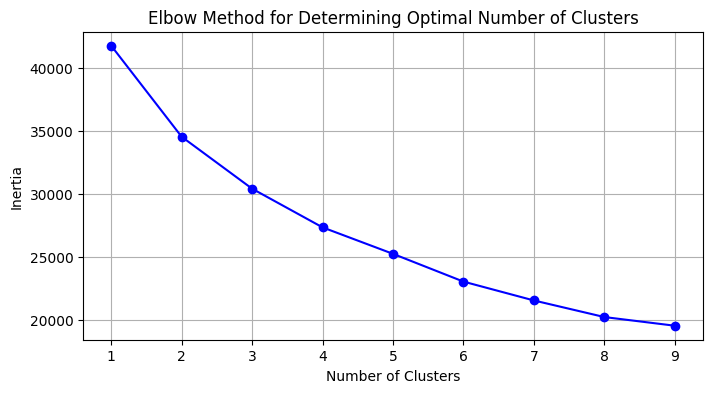

In [7]:
###### PROBLEM 3 ######

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Determining the appropriate number of clusters using the Elbow Method for original variables
inertia = []
range_values = range(1, 10)

for i in range_values:
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(pca_data_standardized)
    inertia.append(kmeans.inertia_)

# Plotting the Elbow Method graph
plt.figure(figsize=(8, 4))
plt.plot(range_values, inertia, marker='o', linestyle='-', color='blue')
plt.title('Elbow Method for Determining Optimal Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will cha

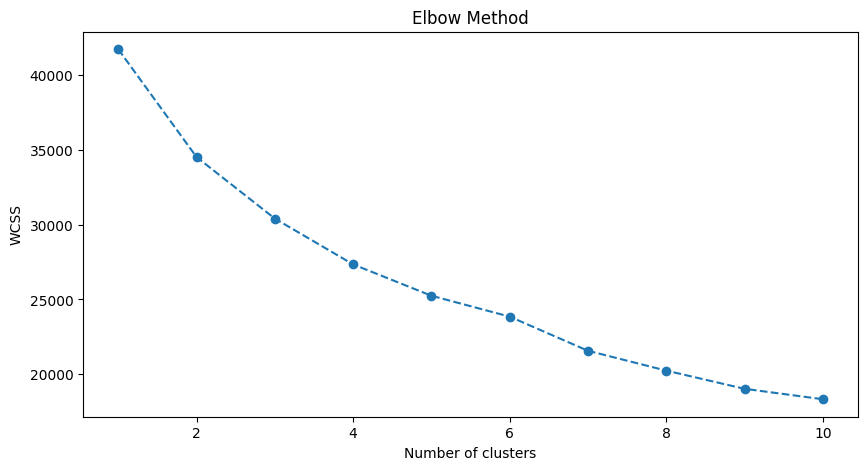

[41747.99999999999,
 34531.07982879707,
 30413.515629543806,
 27348.048459794132,
 25249.39721147227,
 23849.39849605134,
 21564.770960021793,
 20237.54757565334,
 19019.283925716347,
 18322.045870452548]

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Function to perform Elbow Method analysis
def perform_elbow_method(data, max_clusters=10):
    wcss = []  # Within-cluster sum of squares
    for i in range(1, max_clusters+1):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
        kmeans.fit(data)
        wcss.append(kmeans.inertia_)
    
    plt.figure(figsize=(10, 5))
    plt.plot(range(1, max_clusters+1), wcss, marker='o', linestyle='--')
    plt.title('Elbow Method')
    plt.xlabel('Number of clusters')
    plt.ylabel('WCSS')
    plt.show()

    return wcss

# Performing Elbow Method analysis on the original 12 variables
perform_elbow_method(pca_data_standardized)


In [8]:
# Performing K-Means clustering with 3 clusters on the original variables
kmeans_original = KMeans(n_clusters=3, random_state=0)
clusters_original = kmeans_original.fit_predict(pca_data_standardized)

# Adding the cluster labels to the original data
clustered_data_original = pca_data.copy()
clustered_data_original['Cluster'] = clusters_original

# Performing K-Means clustering with 3 clusters on the data transformed by the important PCs
pca_transformed_data = pca.transform(pca_data_standardized)[:, :7]  # Using only the first 7 PCs
kmeans_pca = KMeans(n_clusters=3, random_state=0)
clusters_pca = kmeans_pca.fit_predict(pca_transformed_data)

# Adding the cluster labels to the PCA-transformed data
clustered_data_pca = pd.DataFrame(pca_transformed_data, columns=[f'PC{i+1}' for i in range(7)])
clustered_data_pca['Cluster'] = clusters_pca

# Summarizing the characteristics of each cluster for the original and PCA-based data
cluster_summary_original = clustered_data_original.groupby('Cluster').mean()
cluster_summary_pca = clustered_data_pca.groupby('Cluster').mean()

cluster_summary_original, cluster_summary_pca


c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
c:\Users\Munim Hasan Wasi\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


(           gender       age   edu_cat   emp_fin  income_quartile    health  \
 Cluster                                                                      
 0        0.516129  2.213400  0.707196  0.461538         1.153846  1.488834   
 1        0.361254  1.462487  1.587873  0.064748         2.176259  1.204008   
 2        0.413274  2.792035  0.466372  0.450442         1.223009  1.701770   
 
          disability  disc_wage  disc_jobedu  disc_promotion  disc_resign  \
 Cluster                                                                    
 0          0.039702   0.523573     1.550868        1.732010     1.129032   
 1          0.005653   0.068859     0.023124        0.089928     0.128469   
 2          0.054867   0.185841     0.038053        0.111504     0.043363   
 
          disc_edu  
 Cluster            
 0        0.558313  
 1        0.010277  
 2        0.042478  ,
               PC1       PC2       PC3       PC4       PC5       PC6       PC7
 Cluster                       

In [10]:
###### QUESTION 4 ######


# Building the logistic regression model for prediction
# We use the same dataset and variables as before, but now for prediction

# Separating the dataset into two parts: 
# - One with 'disc_hire' as 0 or 1 for training the model
# - The other with 'disc_hire' as NA for making predictions

training_data = data[data['disc_hire'].notna()]
prediction_data = data[data['disc_hire'].isna()]

# Preparing the training data
X_train = training_data.drop('disc_hire', axis=1)  # Explanatory variables
y_train = training_data['disc_hire']               # Response variable

# Adding a constant to the model (intercept)
X_train = sm.add_constant(X_train)

# Fitting the logistic regression model for prediction
logistic_model_prediction = sm.Logit(y_train, X_train).fit()

# Preparing the prediction data (excluding the response variable)
X_predict = prediction_data.drop('disc_hire', axis=1)
X_predict = sm.add_constant(X_predict)

# Making predictions for the 97 participants
predicted_responses = logistic_model_prediction.predict(X_predict)

# Adding predicted responses to the prediction dataset
prediction_data['predicted_disc_hire'] = predicted_responses

# Displaying the first few rows of the prediction dataset with predicted responses
prediction_data.head()

Optimization terminated successfully.
         Current function value: 0.310260
         Iterations 7


C:\Users\Munim Hasan Wasi\AppData\Local\Temp\ipykernel_14344\3805184391.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['predicted_disc_hire'] = predicted_responses


,disc_hire,gender,age,edu_cat,mariage,emp_fin,income_quartile,birth_region,health,disability,residence,disc_wage,disc_jobedu,disc_promotion,disc_resign,disc_edu,disc_home,disc_social,predicted_disc_hire
58,NaN,1,3,2,1,1,2,0,1,0,1,2,2,2,2,2,1,1,0.997062
104,NaN,1,3,0,1,1,1,0,2,0,1,2,2,2,2,0,0,0,0.995204
141,NaN,1,1,2,1,0,3,0,1,0,1,1,2,1,2,2,1,1,0.806745
246,NaN,0,4,0,1,0,3,0,3,0,1,2,2,2,2,0,0,2,0.999173
273,NaN,0,3,1,1,0,2,1,1,0,1,2,0,0,0,0,0,0,0.966782
